In [ ]:
# !pip install --upgrade tensorflow
# !python --version
# !pip install numpy==1.26.4 scipy==1.13.1 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 --force-reinstall

In [ ]:
# !pip install --upgrade numpy
# !pip install --force-reinstall --no-cache-dir gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 59.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 78.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 146.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 269.2 MB/s eta 0:00:00
   ━━━━━━━━

## Importing Necessary Dependecies

In [3]:
import os
import re
import random
import pickle
import seaborn as sns
import pandas as pd
import numpy as np
import nltk
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from tensorflow.keras.layers import SimpleRNN
from keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import load_model
from keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
nltk.download('wordnet', force=True)
nltk.download('omw-1.4', force=True)
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /home/siddhu/nltk_data...
[nltk_data] Downloading package omw-1.4 to /home/siddhu/nltk_data...
[nltk_data] Downloading package stopwords to /home/siddhu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading our dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/Hotel_Reviews.csv')
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Checking Initial Target Count (Rating)

In [ ]:
df.Rating.value_counts()

,count
Rating,
5,9054
4,6039
3,2184
2,1793
1,1421


Mapping Numerical Ratings to 3 Sentiment Labels

In [ ]:
sentiment_mappings = {
    1: 'negative',
    2: 'negative',
    3: 'neutral',
    4: 'neutral',
    5: 'positive'
}

df['Sentiment'] = df['Rating'].map(sentiment_mappings)

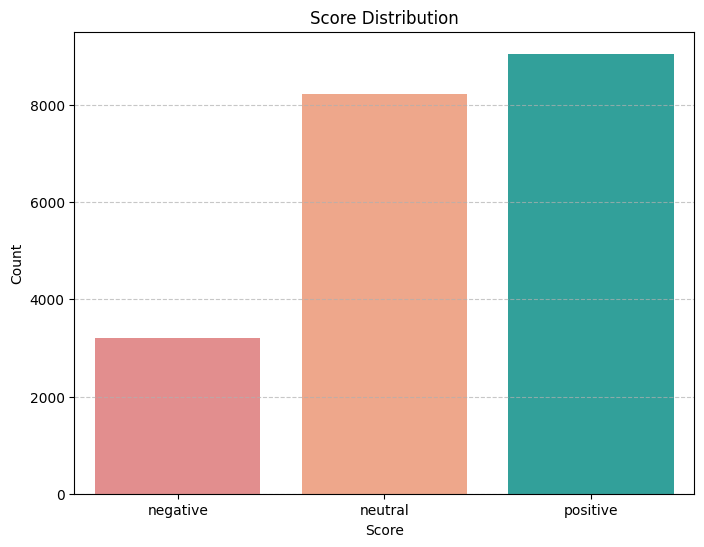

In [ ]:
score_counts = df['Sentiment'].value_counts().sort_index()
# Define colors for each bar
colors = ['lightcoral', 'lightsalmon', 'lightseagreen']
plt.figure(figsize=(8, 6))
sns.barplot(x=score_counts.index, y=score_counts, palette=colors, hue=score_counts.index, legend=False)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)  # Adding grid
plt.show()

In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
positive,9054
neutral,8223
negative,3214


## Text Augmentation for Negative Reviews

In [ ]:
from nltk.corpus import wordnet

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            if lemma.name().lower() != word.lower():
                synonyms.add(lemma.name().replace('_', ' '))
    return list(synonyms)

def synonym_replacement(text, n=2):
  words = text.split()
  new_words = words.copy()
  random_word_list = list(set([word for word in words if get_synonyms(word)]))
  random.shuffle(random_word_list)
  num_replaced = 0
  for random_word in random_word_list:
      synonyms = get_synonyms(random_word)
      if synonyms:
          synonym = random.choice(synonyms)
          new_words = [synonym if word == random_word else word for word in new_words]
          num_replaced += 1
      if num_replaced >= n:
          break
  return ' '.join(new_words)

# Example Usage
text = "The quick brown fox jumps over the lazy dog"
print("Original text : ", text)
print("Output : ", synonym_replacement(text, n=2))

Original text :  The quick brown fox jumps over the lazy dog
Output :  The quick John Brown fox pass over over the lazy dog


In [ ]:
negatives = df[df['Sentiment'] == 'negative']
augmented = negatives.copy()
augmented['Review'] = augmented['Review'].apply(lambda x: synonym_replacement(x, n=2))

In [ ]:
augmented['Sentiment'] = 'negative'
df_augmented = pd.concat([df, augmented], ignore_index=True)

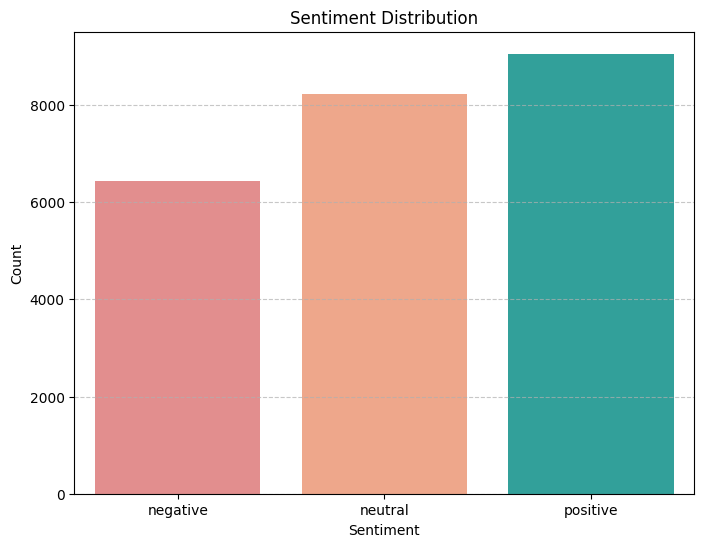

In [ ]:
score_counts = df_augmented['Sentiment'].value_counts().sort_index()
# Define colors for each bar
colors = ['lightcoral', 'lightsalmon', 'lightseagreen']
plt.figure(figsize=(8, 6))
sns.barplot(x=score_counts.index, y=score_counts, palette=colors, hue=score_counts.index, legend=False)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)  # Adding grid
plt.show()

In [ ]:
df_augmented['Sentiment'].value_counts()

,count
Sentiment,
positive,9054
neutral,8223
negative,6428


## Downsampling

In [ ]:
# Group by sentiment
positive_df = df_augmented[df_augmented['Sentiment'] == 'positive']
neutral_df = df_augmented[df_augmented['Sentiment'] == 'neutral']
negative_df = df_augmented[df_augmented['Sentiment'] == 'negative']

# Downsample majority classes to match minority class count
positive_downsampled = positive_df.sample(n=6428, random_state=42)
neutral_downsampled = neutral_df.sample(n=6428, random_state=42)

# Combine all downsampled data
balanced_df = pd.concat([positive_downsampled, neutral_downsampled, negative_df])
# Optional: shuffle the combined dataframe
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

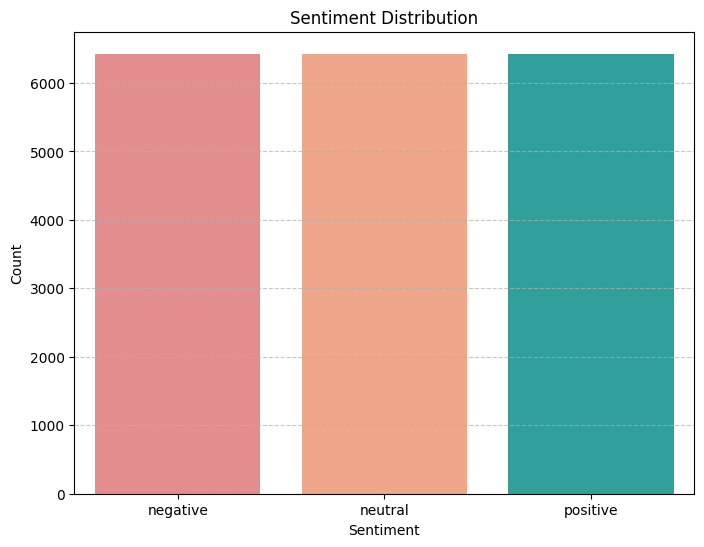

In [ ]:
score_counts = balanced_df['Sentiment'].value_counts().sort_index()
# Define colors for each bar
colors = ['lightcoral', 'lightsalmon', 'lightseagreen']
plt.figure(figsize=(8, 6))
sns.barplot(x=score_counts.index, y=score_counts, palette=colors, hue=score_counts.index, legend=False)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)  # Adding grid
plt.show()

## Text Cleaning

Lowercasing

In [ ]:
balanced_df['Review'] = balanced_df['Review'].str.lower()

In [ ]:
def remove_urls_mentions_hashtags(text):
    url_pattern = r'https?://(?:www\.)?\S+'
    mention_pattern = r'@\w+'
    hashtag_pattern = r'#\w+'
    combined_pattern = f'({url_pattern})|({mention_pattern})|({hashtag_pattern})'
    cleaned_text = re.sub(combined_pattern, ' ', text)
    return cleaned_text

In [ ]:
def remove_nums_special_chars(text):
    pattern = r'[^a-zA-Z\s]'
    cleaned_text = re.sub(pattern, ' ', text)
    return cleaned_text

In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 10.3 MB/s eta 0:00:00


In [ ]:
import contractions

def expand_and_clean_text(text):
  # Step 1: Expand contractions in the entire text
  expanded_text = contractions.fix(text)
  # Step 2: Replace multiple spaces with a single space and strip leading/trailing spaces
  cleaned_text = re.sub(r'\s+', ' ', expanded_text).strip()
  return cleaned_text

text = '''I'll be there within 5 min. Shouldn't you be there too?
          I'd love to see u there my dear. It's awesome to meet new friends.
          We've been waiting for this day for so long.'''

result = expand_and_clean_text(text)
print(result)

I will be there within 5 min. Should not you be there too? I would love to see you there my dear. It is awesome to meet new friends. We have been waiting for this day for so long.


In [ ]:
STOPWORDS = set(stopwords.words('english'))
print(list(STOPWORDS))
lemmatizer = WordNetLemmatizer()

def stopwords_lemmatization(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word, pos='v') for word in words if word.lower() not in STOPWORDS]
    return ' '.join(lemmatized_words)

["he'll", 'has', "it'd", 'while', "wouldn't", 'herself', "doesn't", "we'll", 'most', "i've", 'when', 'by', 'against', 'down', 'after', "they'd", 'hadn', 'if', "she'll", 'then', 'where', 'he', 'there', "mustn't", 'about', 've', "won't", 'further', 'just', "we've", 'don', 'of', 'what', 'for', "mightn't", 'himself', 'why', "couldn't", 'no', 'once', 'other', 'wasn', 'because', "it'll", 'which', 'will', 'am', 'won', 'they', 'during', 'theirs', "you'd", 'didn', 'through', "should've", 'are', 'such', 'have', "haven't", 'isn', 'mightn', "shouldn't", 'the', 'a', 'we', 'an', "he'd", 'll', 'now', 'my', 'under', 'weren', 'o', 'yourself', 'she', 'but', 'him', 'up', 'so', 'wouldn', 'does', 'that', 'on', 'yourselves', 'before', "didn't", 'both', "don't", 'shouldn', 'than', 'hasn', "they're", "they'll", "we'd", "you'll", 'been', 'nor', 'couldn', "it's", 'to', 'ain', "she'd", 'these', 'all', 'or', 'having', 'her', 'your', "aren't", 'did', 'y', "hadn't", 'do', 'our', 'his', 'again', 'needn', 'own', 't',

Text Cleaning Pipeline

In [ ]:
def text_cleaning_pipeline(df, text_column):
    for i, row in tqdm(df.iterrows(), total=len(df)):
        text = row[text_column]
        cleaned_text = remove_urls_mentions_hashtags(text)
        cleaned_text = remove_nums_special_chars(cleaned_text)
        cleaned_text = expand_and_clean_text(cleaned_text)
        cleaned_text = stopwords_lemmatization(cleaned_text)
        df.at[i, 'cleaned_text'] = cleaned_text
    return df

In [ ]:
cleaned_df = text_cleaning_pipeline(df=balanced_df, text_column='Review')

  0%|          | 0/19284 [00:00<?, ?it/s]

In [ ]:
cleaned_df.head()

,Review,Rating,Sentiment,cleaned_text
0,rated husband travelled quite extensively cari...,2,negative,rat husband travel quite extensively caribbean...
1,absolutely charming hearing horror story regar...,4,neutral,absolutely charm hear horror story regard evil...
2,beautiful facilities overall highly disappoint...,2,negative,beautiful facilities overall highly disappoint...
3,"not great hotel okay no, not central despite r...",3,neutral,great hotel okay central despite review say bu...
4,location location location august 07 mom staye...,4,neutral,location location location august mom stay hot...


In [ ]:
rand_idx = random.randint(0, len(cleaned_df) - 1)
print(f"cleaned_df['Review'][{rand_idx}] : \n=> {cleaned_df['Review'][rand_idx]}\n")
print(f"cleaned_df['cleaned_text'][{rand_idx}] : \n=> {cleaned_df['cleaned_text'][rand_idx]}")

cleaned_df['Review'][3394] : 
=> 4 star, smallest rooms seen, friday 17th february 2006. barcelona driving looking hotel saw 4 star hotel maritim, looks good outside, reception lobby enormous really lead trust great hotel, haggled price got parking thrown in.they free use tiny sauna tiny steam room free internet/pc.we took room no porterage, silence, okay nice quality tiniest bedroom seen hotel rooms size, not trust glowing terms rooms described tripadvisor writers, not chair room, course not no room chair.tiny bathroom ooops shower room mean no bath shower only.the proximity beach not near beach, major road network hotel.4 star, kidding, nice clean though.okay admit haggle getting room handed key got car free parking went 30 minute drive really good new hampshire ciutat mataro,

cleaned_df['cleaned_text'][3394] : 
=> star smallest room see friday th february barcelona drive look hotel saw star hotel maritim look good outside reception lobby enormous really lead trust great hotel haggl

## Visualize the cleaned data

In [ ]:
from collections import Counter
from itertools import islice

# Combine all cleaned_text entries into one large string
all_text = ' '.join(cleaned_df['cleaned_text'])
# Tokenize and count word frequencies
word_counts = Counter(all_text.split())
# Optional: convert to a regular dictionary
word_count_dict = dict(word_counts)
# Print first 5 items
print(dict(islice(word_count_dict.items(), 5)))
vocab_size = len(word_count_dict)
print("Vocab size : ", vocab_size)

{'rat': 1204, 'husband': 2784, 'travel': 3346, 'quite': 3256, 'extensively': 111}
Vocab size :  38524


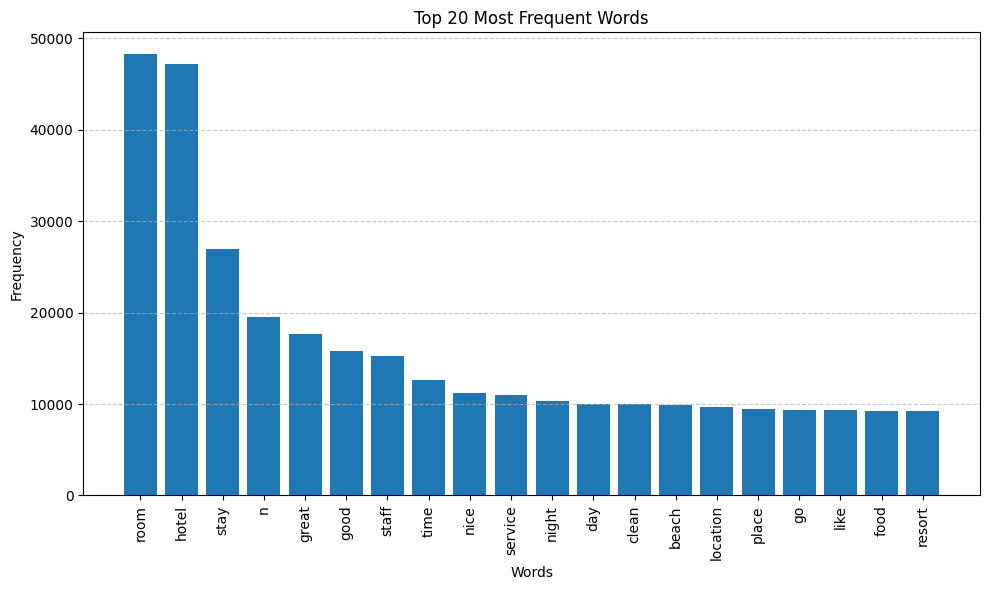

In [ ]:
# Sort the dictionary by count in descending order
top_20_words_sorted = dict(sorted(word_count_dict.items(), key=lambda item: item[1], reverse=True)[:20])

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(top_20_words_sorted.keys(), top_20_words_sorted.values())
plt.xticks(rotation=90)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')

# Enable grid on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

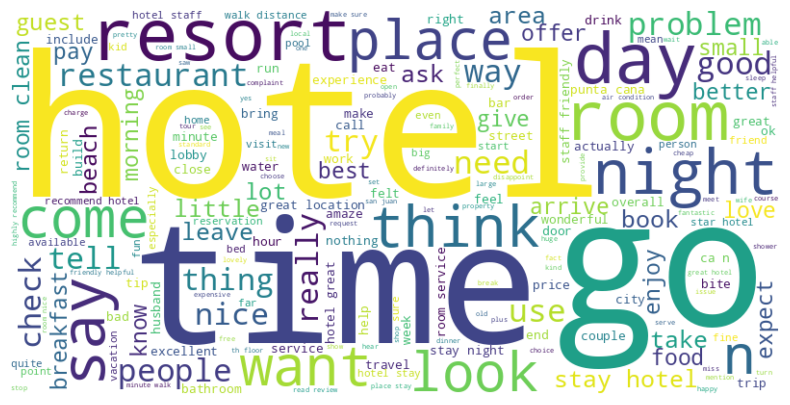

In [ ]:
from wordcloud import WordCloud

text=' '.join(cleaned_df['cleaned_text'])
wordcloud = WordCloud(width=800, height=400,background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

## Splitting the dataset into training and testing set

In [ ]:
texts = cleaned_df['cleaned_text'] # feature
labels = cleaned_df['Sentiment'] # target

In [ ]:
# Split dataset into 80% training and 20% testing with stratification

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)

print("X_train shape : ", X_train.shape)
print("X_test shape : ", X_test.shape)
print("y_train shape : ", y_train.shape)
print("y_test shape : ", y_test.shape)

X_train shape :  (15427,)
X_test shape :  (3857,)
y_train shape :  (15427,)
y_test shape :  (3857,)


## Tokenization and Padding:

In [ ]:
TOKENIZER_PATH = '/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/tokenizer.pkl'

In [ ]:
vocab_size

38524

In [ ]:
# Load if exists, else create, fit and save
if os.path.exists(TOKENIZER_PATH):
    with open(TOKENIZER_PATH, 'rb') as handle:
        tokenizer = pickle.load(handle)
    print("Tokenizer loaded from file.")
else:
    tokenizer = Tokenizer(num_words=10000)
    tokenizer.fit_on_texts(X_train)
    with open(TOKENIZER_PATH, 'wb') as handle:
        pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    print("Tokenizer created and saved to file.")

Tokenizer loaded from file.


In [ ]:
# Convert X_train and X_test texts to sequences of integers
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# Step 2: Find the max sequence length (based on both train and test sequences)
max_sequence_length = max(max([len(seq) for seq in train_sequences]), max([len(seq) for seq in test_sequences]))
print("max_sequence_length : ", max_sequence_length)

max_sequence_length :  1827


In [ ]:
max_sequence_length = 256
# Step 3: Apply padding to ensure uniform sequence length for both
padded_train_sequences = pad_sequences(train_sequences, maxlen=max_sequence_length, padding='post')
padded_test_sequences = pad_sequences(test_sequences, maxlen=max_sequence_length, padding='post')

# Display the max sequence length
print("Maximum Sequence Length:", max_sequence_length)

# Display the padded sequences for training and testing
print("Padded Training Sequences:")
print(padded_train_sequences)

print("Padded Testing Sequences:")
print(padded_test_sequences)

Maximum Sequence Length: 256
Padded Training Sequences:
[[1604    3 2723 ...    0    0    0]
 [4000 1048  710 ...    0    0    0]
 [   6  296    1 ...   20  198  196]
 ...
 [   9    2  362 ...    0    0    0]
 [  68 6470    3 ...    0    0    0]
 [ 137   15 4105 ...    0    0    0]]
Padded Testing Sequences:
[[   9    2    3 ...    0    0    0]
 [   2 1089   71 ...    0    0    0]
 [ 325    2 9501 ...    0    0    0]
 ...
 [  16  132    2 ...    0    0    0]
 [  16    5   50 ...    0    0    0]
 [8084   71 1198 ...    0    0    0]]


## Target Encoding

In [ ]:
y_train.head()

,Sentiment
6794,positive
4745,negative
7338,neutral
7483,neutral
6245,neutral


In [ ]:
y_train_enc = y_train.map({
    'positive': 1,
    'neutral': 0,
    'negative': 2
})
y_train_enc.head()

,Sentiment
6794,1
4745,2
7338,0
7483,0
6245,0


In [ ]:
# Encode string labels to integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# One-hot encode the integer labels
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

print("Encoded Training Labels:")
print(y_train_enc)

print("One-hot Encoded Training Labels:")
print(y_train_cat)

Encoded Training Labels:
[2 0 1 ... 2 0 1]
One-hot Encoded Training Labels:
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [ ]:
print("First Input : \n", padded_train_sequences[0])
print("First output : \n", y_train_cat[0])

First Input : 
 [1604    3 2723   16  597   68    3 2723   16  810  808   26   57   71
 2667  181  990  116  147   41 1619 2568  139   40   75   28  225   49
   76  131    1  328   44    9   39  821    5   10  935   22  131   79
   13    1  747  521  549   48    2 1139  453   15  242 4038   27   88
   36  810  808  331 8035   36   84  670  108   23  242  795  341  161
  424  483   49  116  388    2  116  197   87 2723   16    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0 

In [ ]:
print("Input Shape : ", padded_train_sequences.shape)
print("Output Shape : ", y_train_cat.shape)

Input Shape :  (15427, 256)
Output Shape :  (15427, 3)


## Model Building and Training

In [ ]:
max_sequence_length

256

In [ ]:
# Parameters
EMBEDDING_DIM = 100
MAX_SEQ_LEN = max_sequence_length
VOCAB_SIZE = 10000
NUM_CLASSES = 3
EPOCHS = 15
# Train the model
PATIENCE = 2
BATCH_SIZE = 32
# Early Stooping
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)

### 1. Simple RNN (with a trainable Embedding layer.)

In [ ]:
SAVED_RNN_MODEL_PATH = '/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/rnn_model1.keras'
RNN_IMAGE_PATH = '/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/rnn_model1.png'

In [ ]:
# Build the RNN model
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQ_LEN),
    SimpleRNN(100),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
model1.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
# Build the model explicitly using the input shape
model1.build(input_shape=(None, MAX_SEQ_LEN))
# Model summary
model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 256, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,020,403 (3.89 MB)

 Trainable params: 1,020,403 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Check if the saved model file exists
if not os.path.isfile(SAVED_RNN_MODEL_PATH):
  history1 = model1.fit(
      padded_train_sequences,
      y_train_cat, epochs=EPOCHS,
      batch_size=BATCH_SIZE,
      validation_split=0.2,
      callbacks=[early_stop],
      verbose=1
    )
  model1.save(SAVED_RNN_MODEL_PATH)  # Use Keras model saving
else:
  model1 = load_model(SAVED_RNN_MODEL_PATH)  # Load model properly

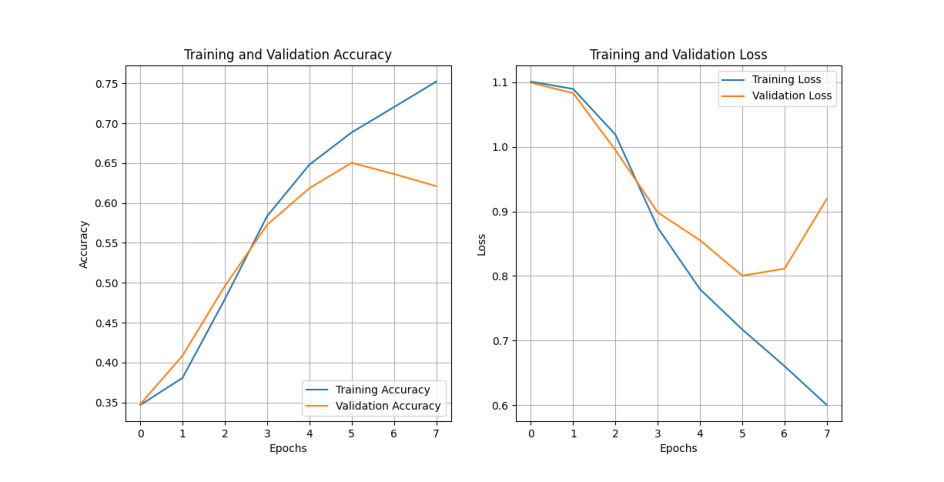

In [ ]:
# Check if the image file already exists
if not os.path.exists(RNN_IMAGE_PATH):
    # If the image file doesn't exist, plot the training and validation metrics
    acc = history1.history['accuracy']
    val_acc = history1.history['val_accuracy']
    loss = history1.history['loss']
    val_loss = history1.history['val_loss']
    epochs_range = range(len(acc))  # Assuming the length of history is the same as the number of epochs

    # Plot training and validation accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    # Save the plot as an image file
    plt.savefig(RNN_IMAGE_PATH)
    plt.show()
else:
    # If the image file exists, load and display the existing image
    img = plt.imread(RNN_IMAGE_PATH)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
loss1, accuracy1 = model1.evaluate(padded_test_sequences, y_test_cat)
print(f"Simple RNN Loss: {loss1}")
print(f"Simple RNN Accuracy: {accuracy1 * 100}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5323 - loss: 1.1053
Simple RNN Loss: 1.0991991758346558
Simple RNN Accuracy: 53.072333335876465


In [ ]:
# Predict the classes on the test set
y_pred = model1.predict(padded_test_sequences)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert the predicted probabilities to class labels
y_test_classes = np.argmax(y_test_cat, axis=1)  # Convert one-hot encoded labels to class labels

121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step


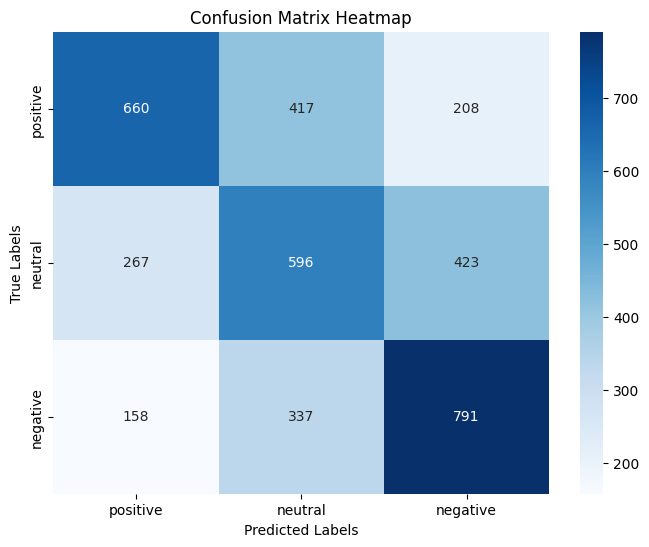

In [ ]:
# Generate confusion matrix
conf_matrix1 = confusion_matrix(y_test_classes, y_pred_classes)
# Create heatmap of confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Classification Report
class_report1 = classification_report(y_test_classes, y_pred_classes)
print("Classification Report:")
print(class_report1)

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.51      0.56      1285
           1       0.44      0.46      0.45      1286
           2       0.56      0.62      0.58      1286

    accuracy                           0.53      3857
   macro avg       0.54      0.53      0.53      3857
weighted avg       0.54      0.53      0.53      3857



### 2. LSTM with a trainable Embedding layer.

In [ ]:
SAVED_LSTM_MODEL_PATH = '/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/lstm_model2.keras'
LSTM_IMAGE_PATH = '/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/lstm_model2.png'

In [ ]:
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQ_LEN),
    LSTM(128),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
])


# Compile the model
model2.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
# Build the model explicitly using the input shape
model2.build(input_shape=(None, MAX_SEQ_LEN))
# Model summary
model2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 256, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117,635 (4.26 MB)

 Trainable params: 1,117,635 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import load_model

# Check if the saved model file exists
if not os.path.isfile(SAVED_LSTM_MODEL_PATH):
    history2 = model2.fit(
        padded_train_sequences, y_train_cat,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.2, callbacks=[early_stop], verbose=1
    )
    model2.save(SAVED_LSTM_MODEL_PATH)  # Use Keras model saving
else:
    model2 = load_model(SAVED_LSTM_MODEL_PATH)  # Load model properly

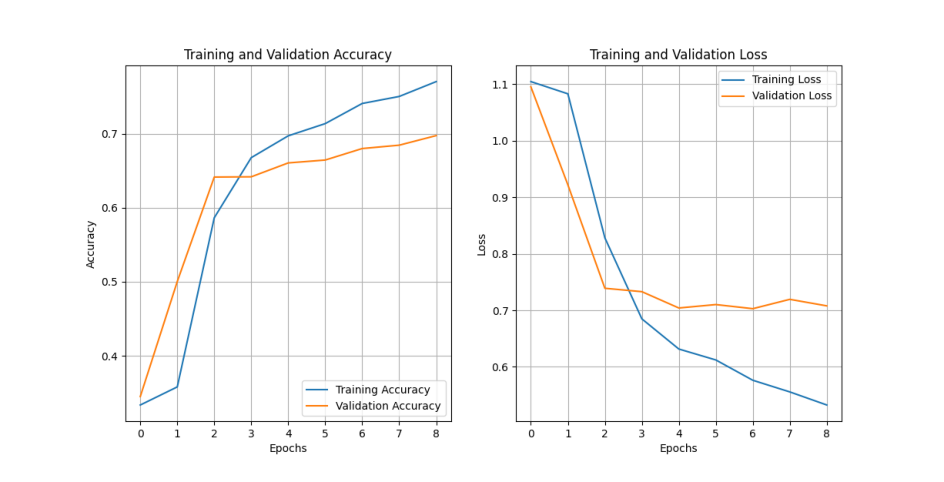

In [ ]:
# Check if the image file already exists
if not os.path.exists(LSTM_IMAGE_PATH):
    # If the image file doesn't exist, plot the training and validation metrics
    acc = history2.history['accuracy']
    val_acc = history2.history['val_accuracy']
    loss = history2.history['loss']
    val_loss = history2.history['val_loss']
    epochs_range = range(len(acc))  # Assuming the length of history is the same as the number of epochs

    # Plot training and validation accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    # Save the plot as an image file
    plt.savefig(LSTM_IMAGE_PATH)
    plt.show()
else:
    # If the image file exists, load and display the existing image
    img = plt.imread(LSTM_IMAGE_PATH)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [ ]:
loss2, accuracy2 = model2.evaluate(padded_test_sequences, y_test_cat)
print(f"LSTM Loss: {loss2}")
print(f"LSTM Accuracy: {accuracy2 * 100}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.5275 - loss: 1.1287
LSTM Loss: 1.1544432640075684
LSTM Accuracy: 52.47601866722107


In [ ]:
# Predict the classes on the test set
y_pred = model2.predict(padded_test_sequences)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert the predicted probabilities to class labels
y_test_classes = np.argmax(y_test_cat, axis=1)  # Convert one-hot encoded labels to class labels

121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step


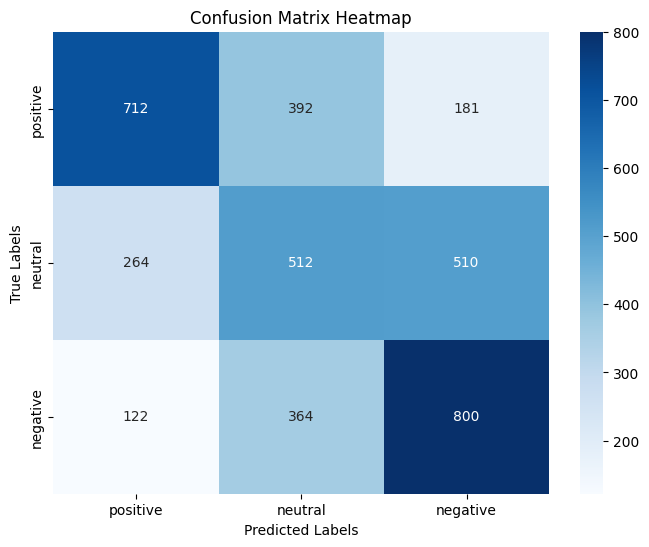

In [ ]:
# Generate confusion matrix
conf_matrix2 = confusion_matrix(y_test_classes, y_pred_classes)

# Create heatmap of confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix2, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Classification Report
class_report2 = classification_report(y_test_classes, y_pred_classes)
print("Classification Report:")
print(class_report2)

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.55      0.60      1285
           1       0.40      0.40      0.40      1286
           2       0.54      0.62      0.58      1286

    accuracy                           0.52      3857
   macro avg       0.53      0.52      0.52      3857
weighted avg       0.53      0.52      0.52      3857



## 3. LSTM with pretrained Word2Vec embeddings.

In [ ]:
SAVED_LSTM_W2V_MODEL_PATH = '/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/lstm_w2v_model.keras'
LSTM_W2V_IMAGE_PATH = '/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/lstm_w2v_model.png'
W2V_MODEL_PATH = "/content/drive/MyDrive/2. Hotel Review Dataset-20250430T051804Z-1-001/2. Hotel Review Dataset/word2vec-google-news-300.kv"

In [ ]:
from gensim import downloader as api
from gensim.models import KeyedVectors

# Check if model already saved
if os.path.exists(W2V_MODEL_PATH):
    print("Loading Word2Vec model from Drive...")
    w2vec_model = KeyedVectors.load(W2V_MODEL_PATH, mmap='r')
else:
    print("Downloading Word2Vec model from Gensim API...")
    w2vec_model = api.load("word2vec-google-news-300")
    print("Saving model to Drive...")
    w2vec_model.save(W2V_MODEL_PATH)

ModuleNotFoundError: No module named 'gensim'

In [ ]:
w2vec_model['football']

memmap([-9.76562500e-02,  3.19824219e-02,  2.57812500e-01,
        -4.15039062e-02,  1.01562500e-01, -1.00585938e-01,
         1.46484375e-01, -1.99218750e-01,  1.53320312e-01,
         6.34765625e-02,  8.39843750e-02, -3.00781250e-01,
         6.34765625e-02,  2.08984375e-01, -2.11914062e-01,
         1.88476562e-01, -8.34960938e-02,  3.28125000e-01,
         2.79296875e-01, -1.40625000e-01, -1.68945312e-01,
         2.04101562e-01,  4.90722656e-02, -6.98852539e-03,
         9.42382812e-02,  9.84191895e-04,  3.12500000e-02,
         2.48046875e-01,  3.35937500e-01,  2.63671875e-01,
         5.68847656e-02,  3.04687500e-01,  1.21582031e-01,
        -1.97265625e-01,  1.72119141e-02,  9.96093750e-02,
         2.27539062e-01, -1.20605469e-01,  1.23535156e-01,
         3.78906250e-01,  2.36816406e-02, -1.86523438e-01,
         6.29882812e-02,  1.52343750e-01,  3.73535156e-02,
        -1.69921875e-01,  1.06445312e-01, -4.98046875e-02,
        -6.20117188e-02,  1.68945312e-01,  4.41894531e-0

In [ ]:
w2vec_model.similarity('basketball', 'football')

0.66824675

In [ ]:
w2vec_model.most_similar('football')

[('soccer', 0.731354832649231),
 ('fooball', 0.7139959335327148),
 ('Football', 0.7124834060668945),
 ('basketball', 0.668246865272522),
 ('footbal', 0.6649289727210999),
 ('athletics', 0.6265192627906799),
 ('gridiron', 0.6191604733467102),
 ('baseball', 0.6162001490592957),
 ('footballl', 0.6069177985191345),
 ('sports', 0.5927178859710693)]

In [ ]:
EMBEDDING_DIM = 300  # Word2Vec Google News vectors have 300 dimensions

# Create embedding matrix
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for padding token
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

In [ ]:
for word, i in word_index.items():
    if word in w2vec_model:
        embedding_matrix[i] = w2vec_model[word]

In [ ]:
# Build the model
model3 = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_SEQ_LEN,
              trainable=False),  # Set to True if fine-tuning embeddings
    LSTM(128),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Compile
model3.compile(optimizer=Adam(learning_rate=0.01),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
# Build with input shape
model3.build(input_shape=(None, MAX_SEQ_LEN))
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 256, 300)       │    10,480,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,700,535 (40.82 MB)

 Trainable params: 220,035 (859.51 KB)

 Non-trainable params: 10,480,500 (39.98 MB)

In [ ]:
from tensorflow.keras.models import load_model

# Check if the saved model file exists
if not os.path.isfile(SAVED_LSTM_W2V_MODEL_PATH):
    history3 = model3.fit(
        padded_train_sequences, y_train_cat,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.2, callbacks=[early_stop], verbose=1
    )
    model3.save(SAVED_LSTM_W2V_MODEL_PATH)  # Use Keras model saving
else:
    model3 = load_model(SAVED_LSTM_W2V_MODEL_PATH)  # Load model properly

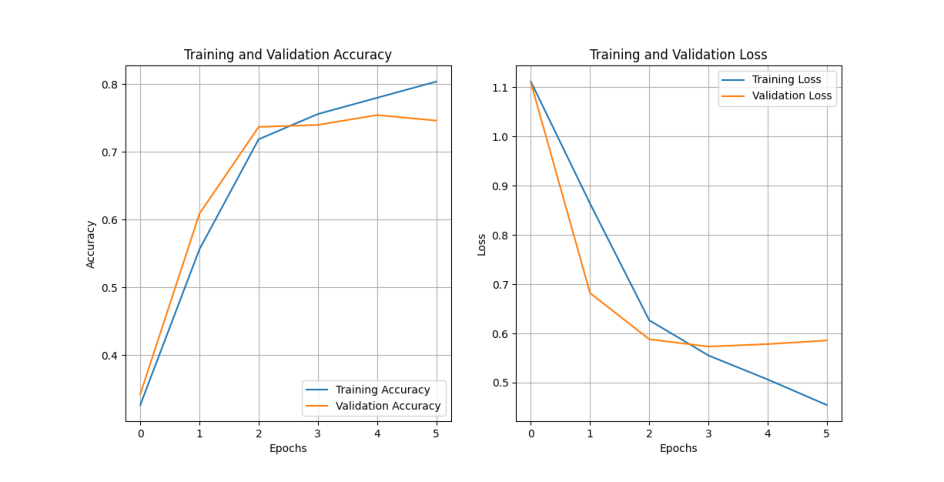

In [ ]:
# Check if the image file already exists
if not os.path.exists(LSTM_W2V_IMAGE_PATH):
    # If the image file doesn't exist, plot the training and validation metrics
    acc = history3.history['accuracy']
    val_acc = history3.history['val_accuracy']
    loss = history3.history['loss']
    val_loss = history3.history['val_loss']
    epochs_range = range(len(acc))  # Assuming the length of history is the same as the number of epochs

    # Plot training and validation accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    # Save the plot as an image file
    plt.savefig(LSTM_W2V_IMAGE_PATH)
    plt.show()
else:
    # If the image file exists, load and display the existing image
    img = plt.imread(LSTM_W2V_IMAGE_PATH)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [ ]:
loss3, accuracy3 = model3.evaluate(padded_test_sequences, y_test_cat)
print(f"LSTM With Word2Vec Loss: {loss3}")
print(f"LSTM With Word2Vec Accuracy : {accuracy3 * 100}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 32s 253ms/step - accuracy: 0.5796 - loss: 0.9623
LSTM With Word2Vec Loss: 0.9847202301025391
LSTM With Word2Vec Accuracy : 58.802175521850586


In [ ]:
# Predict the classes on the test set
y_pred = model3.predict(padded_test_sequences)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert the predicted probabilities to class labels
y_test_classes = np.argmax(y_test_cat, axis=1)  # Convert one-hot encoded labels to class labels

121/121 ━━━━━━━━━━━━━━━━━━━━ 31s 253ms/step


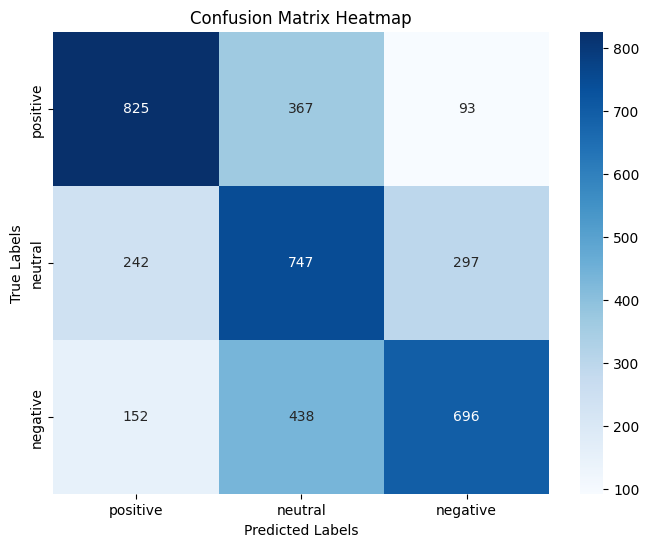

In [ ]:
# Generate confusion matrix
conf_matrix3 = confusion_matrix(y_test_classes, y_pred_classes)

# Create heatmap of confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix3, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
# Classification Report
class_report3 = classification_report(y_test_classes, y_pred_classes)
print("Classification Report:")
print(class_report3)

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.64      0.66      1285
           1       0.48      0.58      0.53      1286
           2       0.64      0.54      0.59      1286

    accuracy                           0.59      3857
   macro avg       0.60      0.59      0.59      3857
weighted avg       0.60      0.59      0.59      3857



## Comparison (Model1 vs Model2 vs Model3)

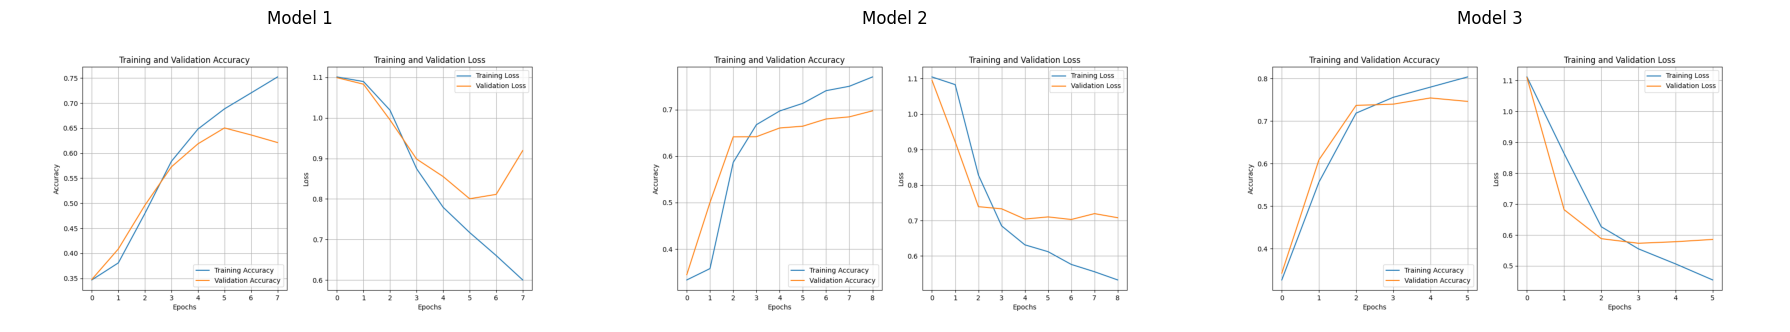

In [ ]:
import matplotlib.image as mpimg

# Paths to your saved images
image_paths = [RNN_IMAGE_PATH , LSTM_IMAGE_PATH, LSTM_W2V_IMAGE_PATH]

# Create a figure with 3 subplots side by side
plt.figure(figsize=(18, 6))  # Adjust width and height as needed

for i, img_path in enumerate(image_paths):
    img = mpimg.imread(img_path)
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Model {i + 1}')  # Optional: Add titles like Model 1, Model 2, etc.

plt.tight_layout()
plt.show()

In [ ]:
accuracy_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM with Word2Vec'],
    'Accuracy': [accuracy1, accuracy2, accuracy3]
})

accuracy_df

,Model,Accuracy
0,Simple RNN,0.530723
1,LSTM,0.526575
2,LSTM with Word2Vec,0.588022


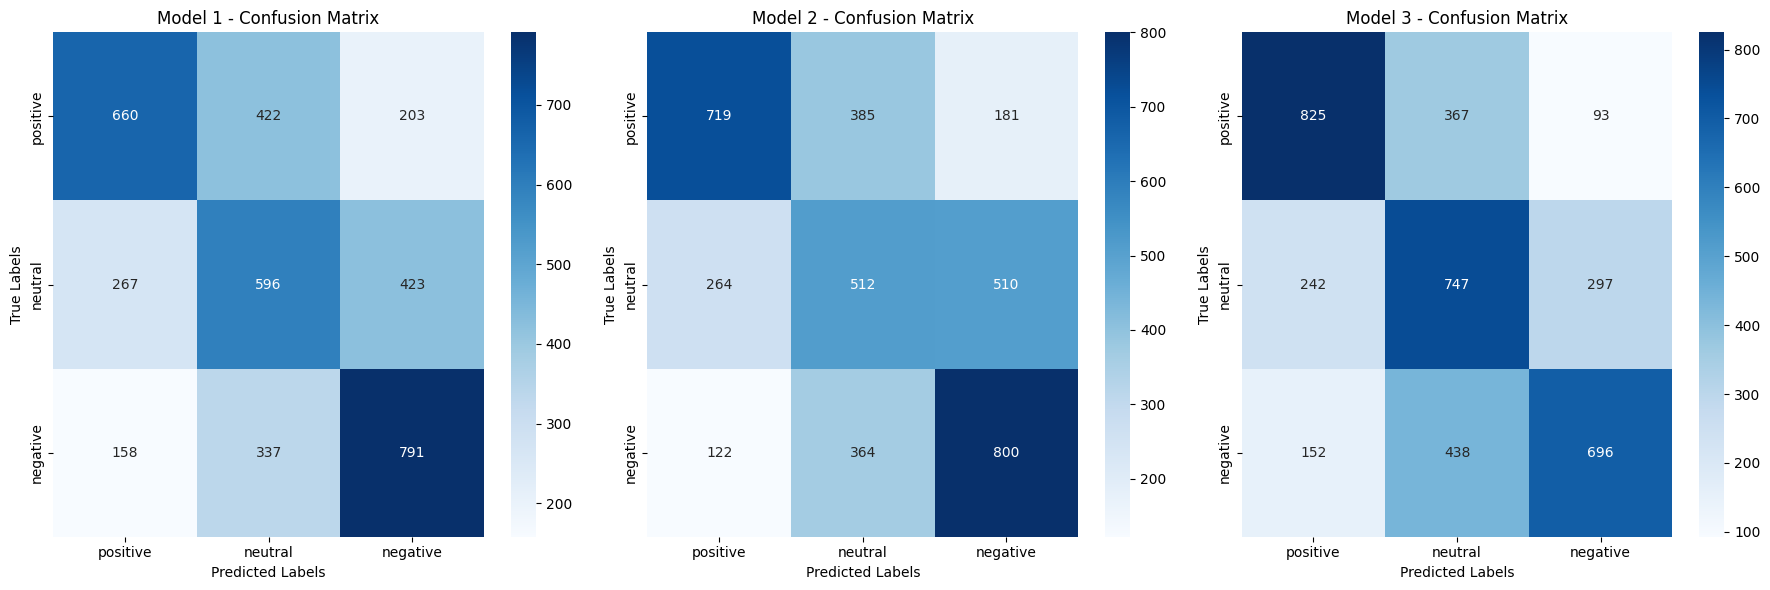

In [ ]:
# List of confusion matrices
conf_matrices = [conf_matrix1, conf_matrix2, conf_matrix3]
titles = ['Model 1 - Confusion Matrix', 'Model 2 - Confusion Matrix', 'Model 3 - Confusion Matrix']
labels = ['positive', 'neutral', 'negative']

# Create subplots
plt.figure(figsize=(18, 6))

for i, (cm, title) in enumerate(zip(conf_matrices, titles)):
    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')

plt.tight_layout()
plt.show()

In [ ]:
print("Classification report for Model 1 : \n", class_report1)

Classificatiopn report for Model 1 : 
               precision    recall  f1-score   support

           0       0.61      0.51      0.56      1285
           1       0.44      0.46      0.45      1286
           2       0.56      0.62      0.59      1286

    accuracy                           0.53      3857
   macro avg       0.54      0.53      0.53      3857
weighted avg       0.54      0.53      0.53      3857



In [ ]:
print("Classification report for Model 2 : \n", class_report2)

Classificatiopn report for Model 2 : 
               precision    recall  f1-score   support

           0       0.65      0.56      0.60      1285
           1       0.41      0.40      0.40      1286
           2       0.54      0.62      0.58      1286

    accuracy                           0.53      3857
   macro avg       0.53      0.53      0.53      3857
weighted avg       0.53      0.53      0.53      3857



In [ ]:
print("Classification report for Model 3 : \n", class_report3)

Classification report for Model 3 : 
               precision    recall  f1-score   support

           0       0.68      0.64      0.66      1285
           1       0.48      0.58      0.53      1286
           2       0.64      0.54      0.59      1286

    accuracy                           0.59      3857
   macro avg       0.60      0.59      0.59      3857
weighted avg       0.60      0.59      0.59      3857

